# Inpainting missing data

Missing data in an image can be an issue, especially when one wants to perform Fourier analysis.
This tutorial explains how to fill-up missing pixels with values which looks "realistic" and introduce as little perturbation as possible for subsequent analysis.
The user should keep the mask nearby and only consider the values of actual pixels and never the one inpainted.

This tutorial will use fully synthetic data to allow comparison between actual (synthetic) data with inpainted values.

The first part of the tutorial is about the generation of a challenging 2D diffraction image with realistic noise and to describe the metric used, then comes the actual tutorial on how to use the inpainting. Finally a benchmark is used based on the metric determined.

## Creation of the image

A realistic challenging image should contain:

* Bragg peak rings. We chose LaB6 as guinea-pig, with very sharp peaks, at the limit of the resolution of the detector
* Some amorphous content
* strong polarization effect
* Poissonian noise


One image will be generated but then multiple ones with different noise to discriminate the effect of the noise from other effects.

In [1]:
%matplotlib inline
# Used for documentation to inline plots into notebook
# %matplotlib widget
# uncomment the later for better UI
from matplotlib.pyplot import subplots
import numpy

In [2]:
import pyFAI
print("Using pyFAI version: ", pyFAI.version)
from pyFAI.gui import jupyter
import pyFAI.test.utilstest
from pyFAI.calibrant import get_calibrant
import time
start_time = time.perf_counter()

Using pyFAI version:  2026.8.0-dev0


In [3]:
detector = pyFAI.detector_factory("Pilatus2MCdTe")
mask = detector.mask.copy()
nomask = numpy.zeros_like(mask)
detector.mask=nomask
ai = pyFAI.load({"detector":detector})
ai.setFit2D(200, 200, 200)
ai.wavelength = 3e-11
print(ai)

Detector Pilatus CdTe 2M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 0.300000 Å
SampleDetDist= 2.000000e-01 m	PONI= 3.440000e-02, 3.440000e-02 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 200.000 mm	Center: x=200.000, y=200.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.300Å


LaB6 Calibrant with 640 reflections at wavelength 3e-11


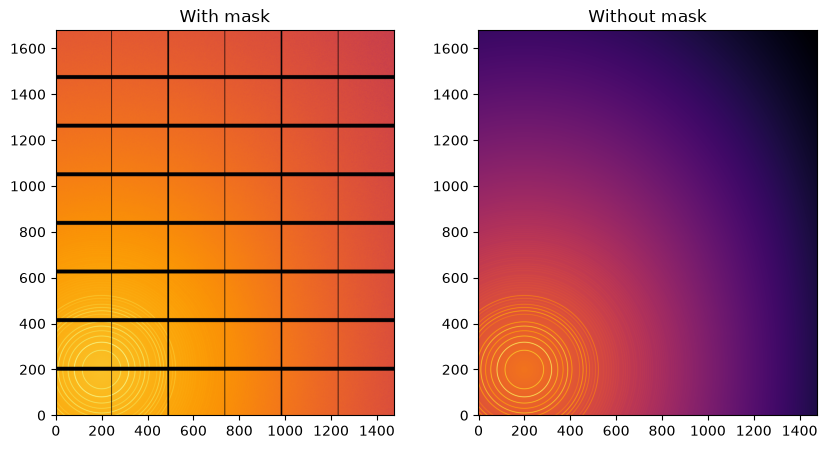

In [4]:
LaB6 = get_calibrant("LaB6")
LaB6.wavelength = ai.wavelength
print(LaB6)
r = ai.array_from_unit(unit="q_nm^-1")
decay_b = numpy.exp(-(r-50)**2/2000)
bragg = LaB6.fake_calibration_image(ai, Imax=1e4, resolution=0.1) * ai.polarization(factor=1.0) * decay_b
decay_a = numpy.exp(-r/100)
amorphous = 1000*ai.polarization(factor=1.0)*ai.solidAngleArray() * decay_a
img_nomask = bragg + amorphous
#Not the same noise function for all images two images
img_nomask1 = numpy.random.poisson(img_nomask)
img_nomask2 = numpy.random.poisson(img_nomask)
img = numpy.random.poisson(img_nomask)
img[numpy.where(mask)] = -1
fig,ax = subplots(1,2, figsize=(10,5))
jupyter.display(img=img, label="With mask", ax=ax[0])
jupyter.display(img=img_nomask, label="Without mask", ax=ax[1]);

Note the aliasing effect on the displayed images.

We will measure now the effect after 1D integration. We do not correct for polarization on purpose to highlight the defect one wishes to wipe out. We use a R-factor to describe the quality of the 1D-integrated signal. 

Between masked and non masked image R= 5.674572153165644
Between two different non-masked images R'= 0.18881780167969184


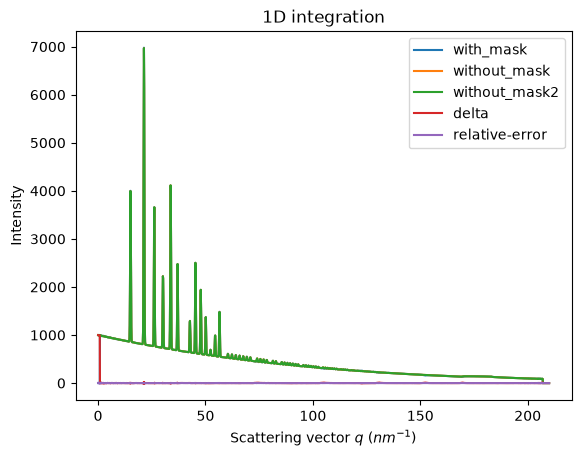

In [5]:
kwargs = {"npt":2000, "unit":"q_nm^-1", "method":("full", "histogram", "cython"), "radial_range":(0,210)}
wo = ai.integrate1d(img_nomask, **kwargs)
wo2 = ai.integrate1d(img_nomask2, **kwargs)
wm = ai.integrate1d(img, mask=mask, **kwargs)
ax = jupyter.plot1d(wm , label="with_mask")
ax.plot(*wo, label="without_mask")
ax.plot(*wo2, label="without_mask2")
ax.plot(wo.radial, wo.intensity-wm.intensity, label="delta")
ax.plot(wo.radial, wo.intensity-wo2.intensity, label="relative-error")
ax.legend()
print("Between masked and non masked image R= {}".format(pyFAI.utils.mathutil.rwp(wm,wo)))
print("Between two different non-masked images R'= {}".format(pyFAI.utils.mathutil.rwp(wo2,wo)))

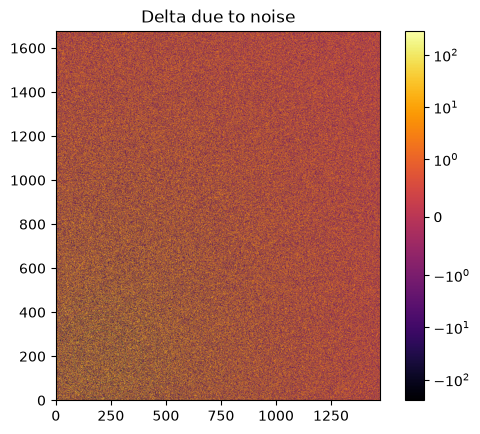

In [6]:
# Effect of the noise on the delta image
fig, ax = subplots()
jupyter.display(img=img_nomask-img_nomask2, label="Delta due to noise", ax=ax)
ax.figure.colorbar(ax.images[0])

## Inpainting

This part describes how to paint the missing pixels for having a "natural-looking image". The delta image contains the difference with the original image

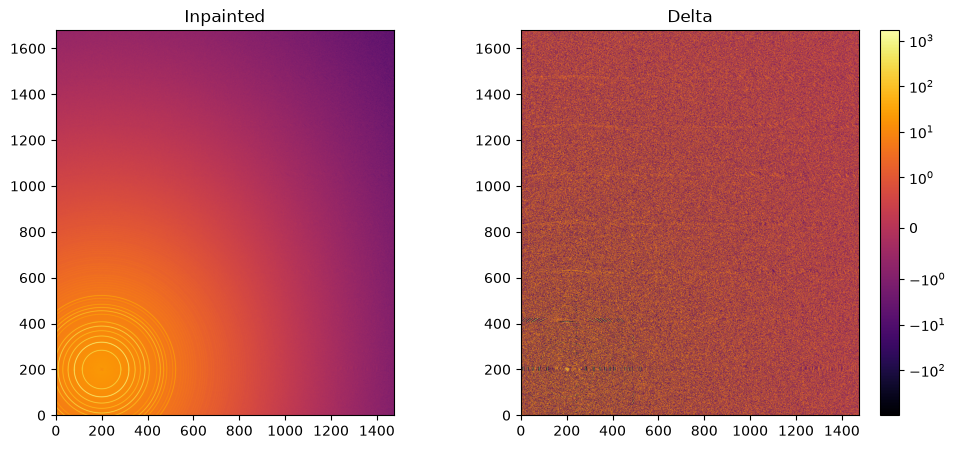

In [7]:
#Inpainting:
inpainted = ai.inpainting(img, mask=mask, 
                          method=("no", "histogram", "cython"),
                          poissonian=True, grow_mask=3)
fig, ax = subplots(1, 2, figsize=(12,5))
jupyter.display(img=inpainted, label="Inpainted", ax=ax[0])
jupyter.display(img=img_nomask-inpainted, label="Delta", ax=ax[1])
ax[1].figure.colorbar(ax[1].images[0]);

R= 0.6411313416360528


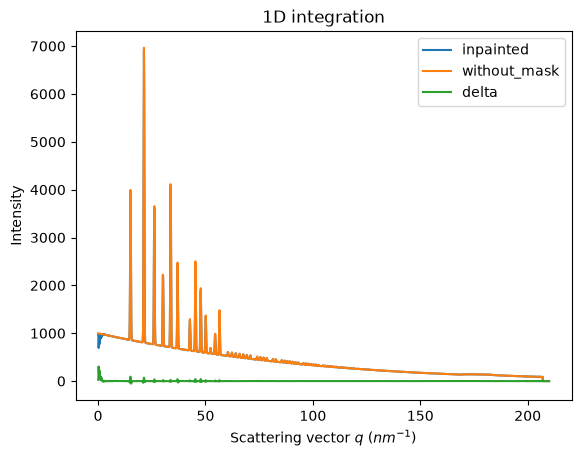

In [8]:
# Comparison of the inpained image with the original one:
wm = ai.integrate1d(inpainted, **kwargs)
wo = ai.integrate1d(img_nomask, **kwargs)
ax = jupyter.plot1d(wm , label="inpainted")
ax.plot(*wo, label="without_mask")
ax.plot(wo.radial, wo.intensity-wm.intensity, label="delta")
ax.legend()
print("R= {}".format(pyFAI.utils.mathutil.rwp(wm,wo)))

One can see by zooming in that the main effect on inpainting is a broadening of the signal in the inpainted region. This could (partially) be addressed by increasing the number of radial bins used in the inpainting.

## Benchmarking and optimization of the parameters

The parameter set depends on the detector, the experiment geometry and the type of signal on the detector. Finer detail require finer slicing.

In [9]:
#Basic benchmarking of execution time for default options:
%timeit inpainted = ai.inpainting(img, mask=mask)

156 ms ± 7.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
wo = ai.integrate1d(img_nomask, **kwargs)
R_best = numpy.finfo("float32").max
best = {}
for m in (("no", "csc", "cython"), ("bbox", "csc","cython"), ("full", "csc","cython")):
    for k in (512, 1024, 2048, 4096):
        ai.reset()
        for i in (0, 1, 2, 4, 8):
            inpainted = ai.inpainting(img, mask=mask, poissonian=True, method=m, npt_rad=k, grow_mask=i)
            wm = ai.integrate1d(inpainted, **kwargs)
            R = pyFAI.utils.mathutil.rwp(wm,wo)
            if R<R_best:
                R_best = R
                best={"method":m,
                      "npt_rad":k, 
                      "grow_mask":i}
            print(f"method: {m} npt_rad={k} grow={i}; R= {R:.3f}")
print("Best configuration:", best)

method: ('no', 'csc', 'cython') npt_rad=512 grow=0; R= 2.334


method: ('no', 'csc', 'cython') npt_rad=512 grow=1; R= 0.837


method: ('no', 'csc', 'cython') npt_rad=512 grow=2; R= 0.560


method: ('no', 'csc', 'cython') npt_rad=512 grow=4; R= 0.499


method: ('no', 'csc', 'cython') npt_rad=512 grow=8; R= 0.448


...

method: ('full', 'csc', 'cython') npt_rad=4096 grow=0; R= 0.960


method: ('full', 'csc', 'cython') npt_rad=4096 grow=1; R= 0.986


method: ('full', 'csc', 'cython') npt_rad=4096 grow=2; R= 0.937


method: ('full', 'csc', 'cython') npt_rad=4096 grow=4; R= 0.979


method: ('full', 'csc', 'cython') npt_rad=4096 grow=8; R= 0.703
Best configuration: {'method': ('bbox', 'csc', 'cython'), 'npt_rad': 4096, 'grow_mask': 2}


CPU times: user 2.96 s, sys: 1.24 s, total: 4.2 s
Wall time: 1.76 s


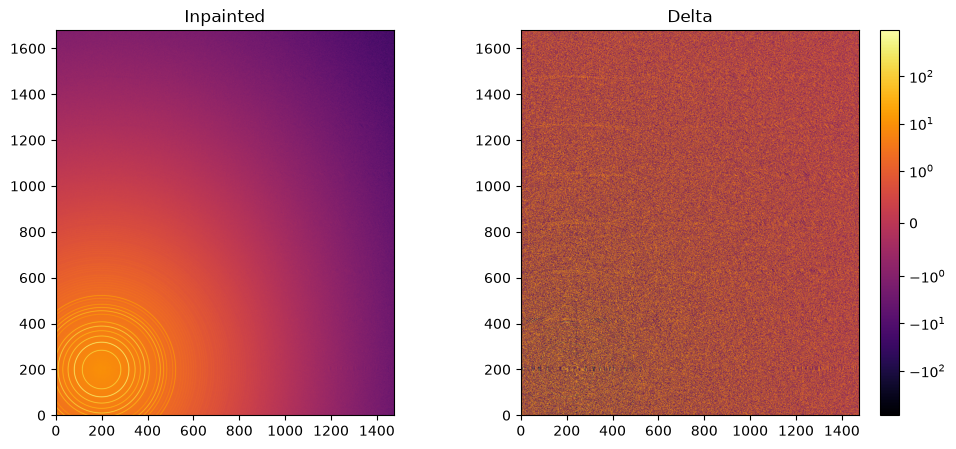

In [11]:
#Inpainting, best solution found:
ai.reset()
%time inpainted = ai.inpainting(img, mask=mask, poissonian=True, **best)
fig, ax = subplots(1, 2, figsize=(12, 5))
jupyter.display(img=inpainted, label="Inpainted", ax=ax[0])
jupyter.display(img=img_nomask-inpainted, label="Delta", ax=ax[1])
ax[1].figure.colorbar(ax[1].images[0]);

R= 0.2649823482992648


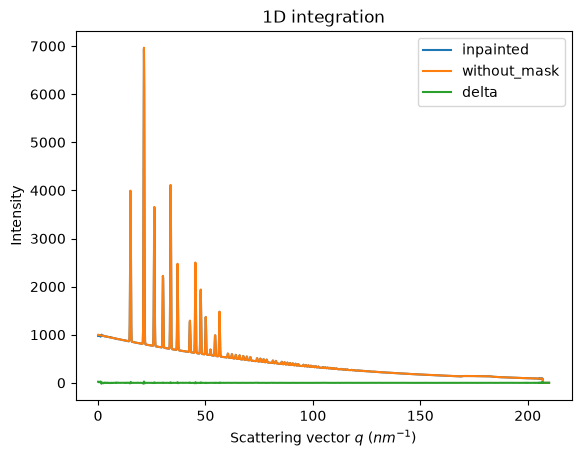

In [12]:
# Comparison of the inpained image with the original one:
wm = ai.integrate1d(inpainted, **kwargs)
wo = ai.integrate1d(img_nomask, **kwargs)
ax = jupyter.plot1d(wm , label="inpainted")
ax.plot(*wo, label="without_mask")
ax.plot(wo.radial, wo.intensity-wm.intensity, label="delta")
ax.legend()
print("R= {}".format(pyFAI.utils.mathutil.rwp(wm,wo)))

## Conclusion

Inpainting is one of the only solutions to fill up the gaps in the detector when Fourier analysis is needed. 
This tutorial explains basically how this is possible using the pyFAI library and how to optimize the parameter set for inpainting. The result may greatly vary with detector position and tilt and the kind of signal (amorphous or more spotty).

In [13]:
print(f"Execution time: {time.perf_counter()-start_time:.3f} s")

Execution time: 68.123 s
